# Analyse Exploratoire des Données (EDA)
## DataCo Supply Chain Dataset

Ce notebook a pour objectif d'explorer le jeu de données afin de :
- Comprendre la structure des données
- Identifier les colonnes pertinentes pour notre projet
- Visualiser les premières tendances
- Préparer les données pour le pipeline ETL

In [ ]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration des visualisations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


## 1. Chargement des données

In [ ]:
# Chargement des données (attention à l'encodage)
df = pd.read_csv('../data/raw/DataCoSupplyChainDataset.csv', encoding='latin-1')

print(f" Nombre d'enregistrements : {len(df):,}")
print(f" Nombre de colonnes : {len(df.columns)}")
print(f" Taille du dataset : {df.shape}")

 Nombre d'enregistrements : 180,519
 Nombre de colonnes : 53
 Taille du dataset : (180519, 53)


## 2. Aperçu des données

In [ ]:
# Aperçu des 5 premières lignes
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
# Aperçu des 5 dernières lignes
df.tail()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,EE. UU.,XXXXXXXXX,Maria,1005,Peterson,XXXXXXXXX,Home Office,NY,1322 Broad Glade,11207.0,7,Fan Shop,40.640930,-73.942711,Pacific Asia,Shanghái,China,1005,1/16/2016 3:40,26043,1004,0.0,0.00,65177,399.980011,0.10,1,399.980011,399.980011,40.000000,Eastern Asia,Shanghái,CLOSED,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,EE. UU.,XXXXXXXXX,Ronald,9141,Clark,XXXXXXXXX,Corporate,CA,7330 Broad Apple Moor,93304.0,7,Fan Shop,35.362545,-119.018700,Pacific Asia,Hirakata,Japón,9141,1/16/2016 1:34,26037,1004,4.0,0.01,65161,399.980011,-1.55,1,399.980011,395.980011,-613.770019,Eastern Asia,Osaka,COMPLETE,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,EE. UU.,XXXXXXXXX,John,291,Smith,XXXXXXXXX,Corporate,CT,97 Burning Landing,6010.0,7,Fan Shop,41.629959,-72.967155,Pacific Asia,Adelaide,Australia,291,1/15/2016 21:00,26024,1004,8.0,0.02,65129,399.980011,0.36,1,399.980011,391.980011,141.110001,Oceania,Australia del Sur,PENDING,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Mary,2813,Smith,XXXXXXXXX,Consumer,PR,2585 Silent Autumn Landing,725.0,7,Fan Shop,18.213350,-66.370575,Pacific Asia,Adelaide,Australia,2813,1/15/2016 20:18,26022,1004,12.0,0.03,65126,399.980011,0.48,1,399.980011,387.980011,186.229996,Oceania,Australia del Sur,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class
180518,PAYMENT,4,4,168.949997,383.980011,Shipping on time,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Andrea,7547,Ortega,XXXXXXXXX,Consumer,PR,697 Little Meadow,725.0,7,Fan Shop,18.290380,-66.370613,Pacific Asia,Nagercoil,India,7547,1/15/2016 18:54,26018,1004,16.0,0.04,65113,399.980011,0.44,1,399.980011,383.980011,168.949997,South Asia,Tamil Nadu,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 18:54,Standard Class


## 3. Informations générales sur les colonnes

In [ ]:
# Types de données et valeurs non-nulles
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

## 4. Statistiques descriptives

In [ ]:
# Statistiques pour les colonnes numériques
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,Longitude,Order Customer Id,Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,-84.915675,6691.379495,36221.894903,692.509764,20.664741,0.101668,90260.000000,141.232550,0.120647,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,21.433241,4162.918106,21045.379569,336.446807,21.800901,0.070415,52111.490959,139.732492,0.466796,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,-158.025986,1.000000,1.000000,19.000000,0.000000,0.000000,1.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,-98.446312,3258.500000,18057.000000,403.000000,5.400000,0.040000,45130.500000,50.000000,0.080000,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,-76.847908,6457.000000,36140.000000,627.000000,14.000000,0.100000,90260.000000,59.990002,0.270000,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,-66.370583,9779.000000,54144.000000,1004.000000,29.990000,0.160000,135389.500000,199.990005,0.360000,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,115.263077,20757.000000,77204.000000,1363.000000,500.000000,0.250000,180519.000000,1999.989990,0.500000,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [ ]:

# Display all column names to find the correct names
print("Column names in the dataset:")
for i, col in enumerate(df.columns):
    print(f"{i+1:2d}. '{col}'")


Column names in the dataset:
 1. 'Type'
 2. 'Days for shipping (real)'
 3. 'Days for shipment (scheduled)'
 4. 'Benefit per order'
 5. 'Sales per customer'
 6. 'Delivery Status'
 7. 'Late_delivery_risk'
 8. 'Category Id'
 9. 'Category Name'
10. 'Customer City'
11. 'Customer Country'
12. 'Customer Email'
13. 'Customer Fname'
14. 'Customer Id'
15. 'Customer Lname'
16. 'Customer Password'
17. 'Customer Segment'
18. 'Customer State'
19. 'Customer Street'
20. 'Customer Zipcode'
21. 'Department Id'
22. 'Department Name'
23. 'Latitude'
24. 'Longitude'
25. 'Market'
26. 'Order City'
27. 'Order Country'
28. 'Order Customer Id'
29. 'order date (DateOrders)'
30. 'Order Id'
31. 'Order Item Cardprod Id'
32. 'Order Item Discount'
33. 'Order Item Discount Rate'
34. 'Order Item Id'
35. 'Order Item Product Price'
36. 'Order Item Profit Ratio'
37. 'Order Item Quantity'
38. 'Sales'
39. 'Order Item Total'
40. 'Order Profit Per Order'
41. 'Order Region'
42. 'Order State'
43. 'Order Status'
44. 'Order Zipcod

In [ ]:
# Statistiques pour les colonnes catégorielles (textes)
df.describe(include=['object'])

,Type,Delivery Status,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Department Name,Market,Order City,Order Country,order date (DateOrders),Order Region,Order State,Order Status,Product Image,Product Name,shipping date (DateOrders),Shipping Mode
count,180519,180519,180519,180519,180519,180519,180519,180511,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519
unique,4,4,50,563,2,1,782,1109,1,3,46,7458,11,5,3597,164,65752,23,1089,9,118,118,63701,4
top,DEBIT,Late delivery,Cleats,Caguas,EE. UU.,XXXXXXXXX,Mary,Smith,XXXXXXXXX,Consumer,PR,9126 Wishing Expressway,Fan Shop,LATAM,Santo Domingo,Estados Unidos,1/4/2017 2:28,Central America,Inglaterra,COMPLETE,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,4/17/2015 22:16,Standard Class
freq,69295,98977,24551,66770,111146,180519,65150,64104,180519,93504,69373,122,66861,51594,2211,24840,5,28341,6722,59491,24515,24515,10,107752


## 5. Analyse des valeurs manquantes

Colonnes avec des valeurs manquantes :
Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64


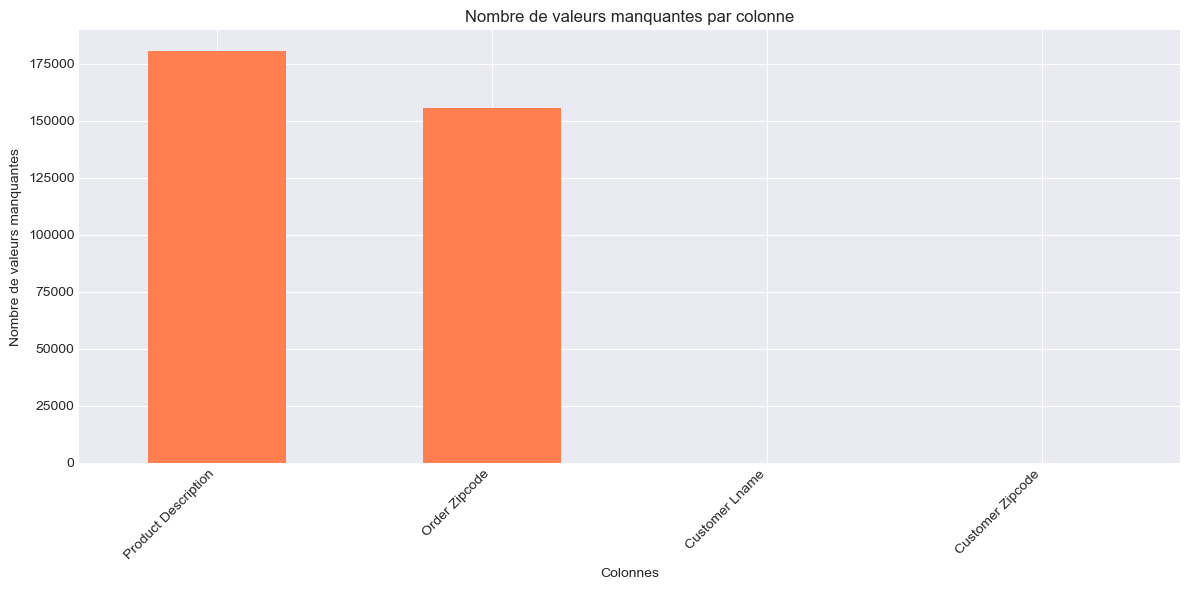

In [ ]:
# Compter les valeurs manquantes par colonne
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)

print("Colonnes avec des valeurs manquantes :")
print(missing_values)

# Visualisation des valeurs manquantes
plt.figure(figsize=(12, 6))
missing_values.plot(kind='bar', color='coral')
plt.title('Nombre de valeurs manquantes par colonne')
plt.xlabel('Colonnes')
plt.ylabel('Nombre de valeurs manquantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Sélection des colonnes pertinentes

Pour notre projet, nous allons nous concentrer sur les colonnes qui nous aideront à :
- Analyser les performances logistiques
- Évaluer les transporteurs
- Prédire les risques de retard

In [ ]:
# Liste des colonnes pertinentes
colonnes_pertinentes = [
    'Order Id',                 # Identifiant de commande
    'Customer City',            # Ville du client
    'Order Country',            # Pays du client
    'order date (DateOrders)',  # Date de commande
    'shipping date (DateOrders)', # Date d'expédition
    'Days for shipping (real)',  # Délai réel de livraison
    'Days for shipment (scheduled)', # Délai prévu
    'Late_delivery_risk',       # Risque de retard (cible)
    'Delivery Status',          # Statut de livraison
    'Order Item Quantity',      # Quantité
    'Sales per customer',       # Ventes par client
    'Benefit per order',        # Bénéfice par commande
    'Category Name',            # Catégorie de produit
    'Shipping Mode',            # Mode d'expédition
    'Customer Segment',         # Segment client
]

# Créer un sous-ensemble
df_subset = df[colonnes_pertinentes].copy()

print(f"Sous-ensemble créé : {df_subset.shape}")
print(f"Colonnes sélectionnées : {len(df_subset.columns)}")

Sous-ensemble créé : (180519, 15)
Colonnes sélectionnées : 15


In [ ]:
# Aperçu du sous-ensemble
df_subset.head()

,Order Id,Customer City,Order Country,order date (DateOrders),shipping date (DateOrders),Days for shipping (real),Days for shipment (scheduled),Late_delivery_risk,Delivery Status,Order Item Quantity,Sales per customer,Benefit per order,Category Name,Shipping Mode,Customer Segment
0,77202,Caguas,Indonesia,1/31/2018 22:56,2/3/2018 22:56,3,4,0,Advance shipping,1,314.640015,91.250000,Sporting Goods,Standard Class,Consumer
1,75939,Caguas,India,1/13/2018 12:27,1/18/2018 12:27,5,4,1,Late delivery,1,311.359985,-249.089996,Sporting Goods,Standard Class,Consumer
2,75938,San Jose,India,1/13/2018 12:06,1/17/2018 12:06,4,4,0,Shipping on time,1,309.720001,-247.779999,Sporting Goods,Standard Class,Consumer
3,75937,Los Angeles,Australia,1/13/2018 11:45,1/16/2018 11:45,3,4,0,Advance shipping,1,304.809998,22.860001,Sporting Goods,Standard Class,Home Office
4,75936,Caguas,Australia,1/13/2018 11:24,1/15/2018 11:24,2,4,0,Advance shipping,1,298.250000,134.210007,Sporting Goods,Standard Class,Corporate


## 7. Analyse de la variable cible : Risque de retard

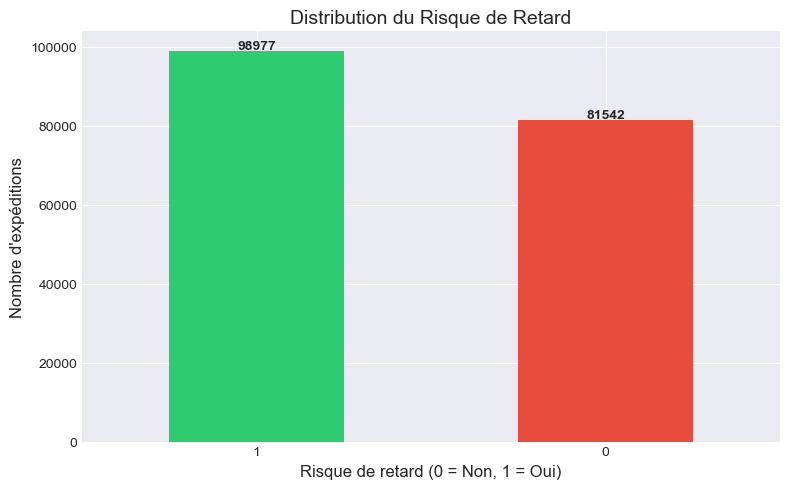

 Taux de retard global : 54.83%


In [ ]:
# Distribution du risque de retard
plt.figure(figsize=(8, 5))
counts = df_subset['Late_delivery_risk'].value_counts()
colors = ['#2ecc71', '#e74c3c']
counts.plot(kind='bar', color=colors)

plt.title('Distribution du Risque de Retard', fontsize=14)
plt.xlabel('Risque de retard (0 = Non, 1 = Oui)', fontsize=12)
plt.ylabel("Nombre d'expéditions", fontsize=12)
plt.xticks(rotation=0)

# Ajouter les valeurs sur les barres
for i, v in enumerate(counts):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Pourcentage
pourcentage_retard = (counts[1] / len(df_subset)) * 100
print(f" Taux de retard global : {pourcentage_retard:.2f}%")

## 8. Analyse des transporteurs

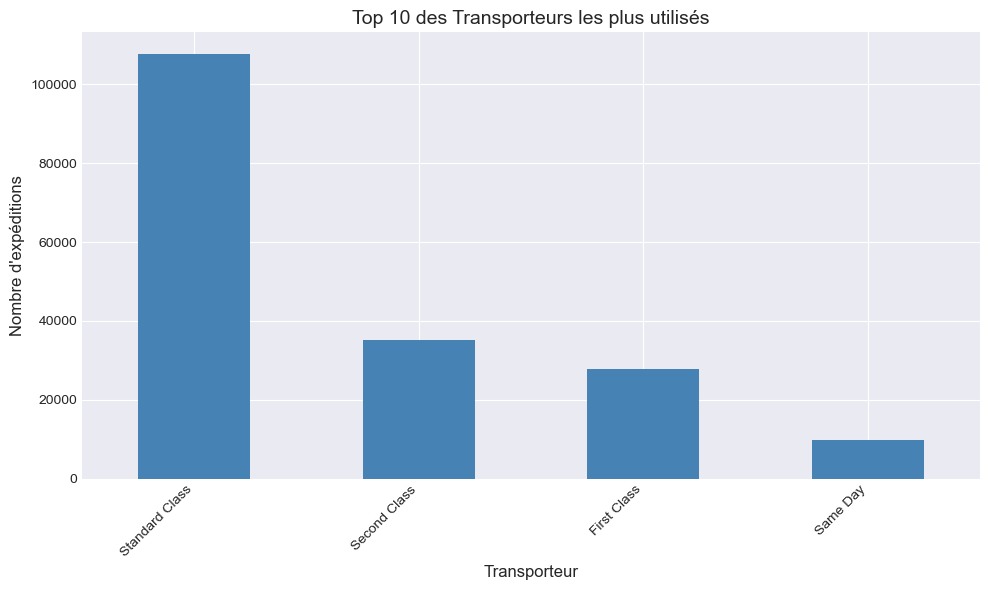

Top 5 des transporteurs :
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


In [ ]:
# Top 10 des transporteurs les plus utilisés
plt.figure(figsize=(10, 6))
top_transporters = df_subset['Shipping Mode'].value_counts().head(10)
top_transporters.plot(kind='bar', color='steelblue')

plt.title('Top 10 des Transporteurs les plus utilisés', fontsize=14)
plt.xlabel('Transporteur', fontsize=12)
plt.ylabel("Nombre d'expéditions", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 5 des transporteurs :")
print(top_transporters.head())

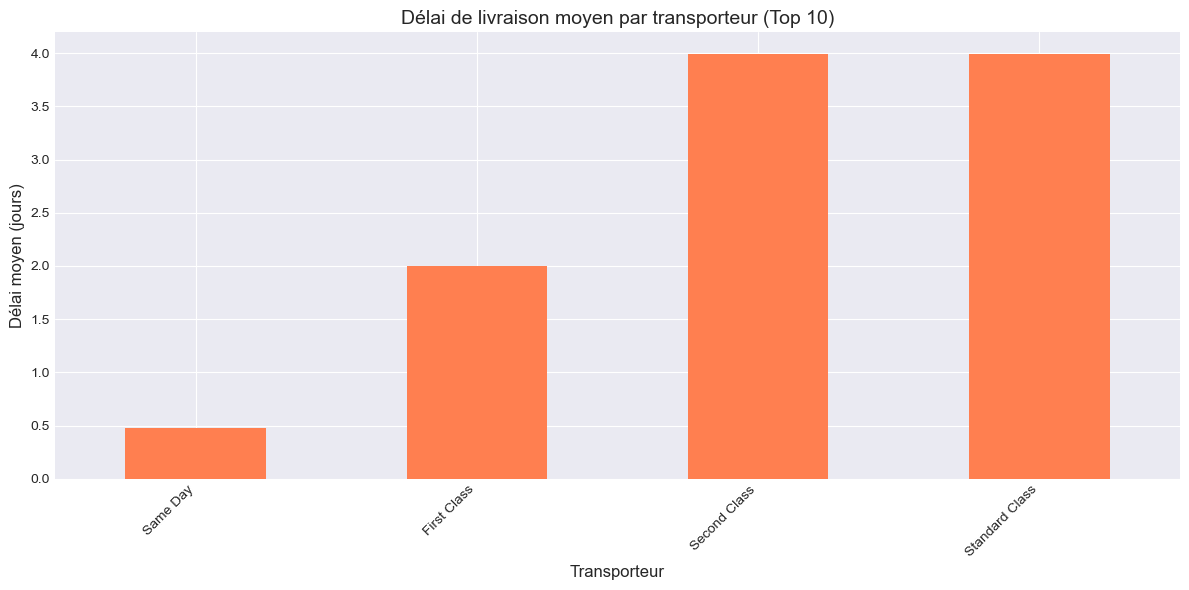

 Transporteurs avec le délai moyen le plus faible:
Shipping Mode
Same Day          0.478279
First Class       2.000000
Second Class      3.990828
Standard Class    3.995907
Name: Days for shipping (real), dtype: float64


In [ ]:
# Délai de livraison moyen par transporteur
plt.figure(figsize=(12, 6))
avg_delay = df_subset.groupby('Shipping Mode')['Days for shipping (real)'].mean().sort_values()

avg_delay.head(10).plot(kind='bar', color='coral')
plt.title('Délai de livraison moyen par transporteur (Top 10)', fontsize=14)
plt.xlabel('Transporteur', fontsize=12)
plt.ylabel('Délai moyen (jours)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(" Transporteurs avec le délai moyen le plus faible:")
print(avg_delay.head(5))

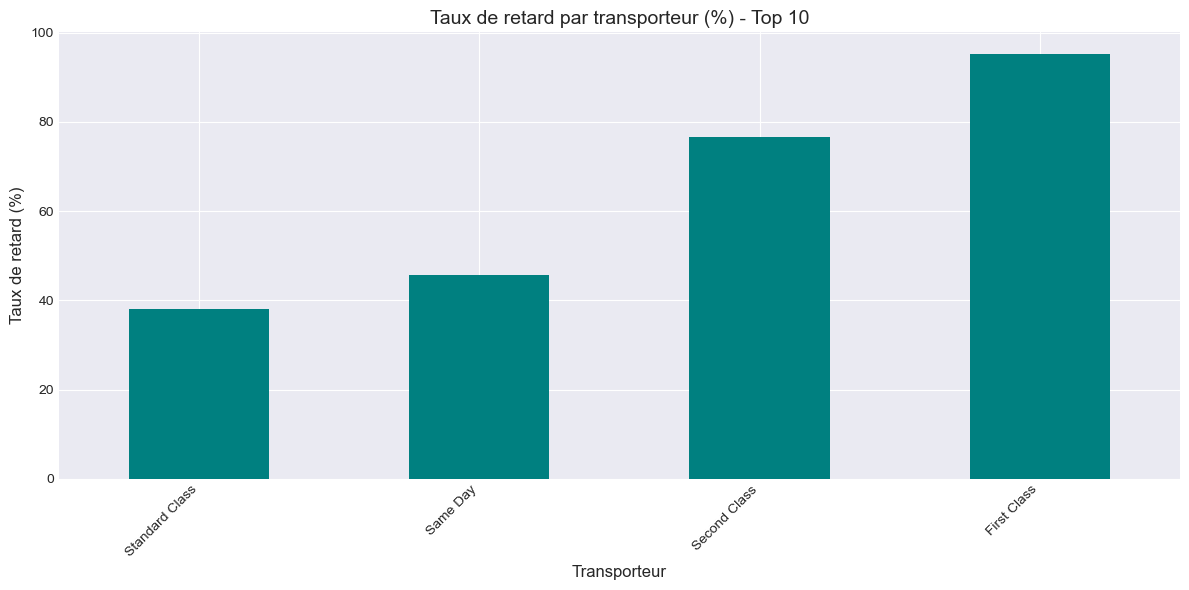

Transporteurs les plus fiables (taux de retard le plus faible) :
Shipping Mode
Standard Class    38.071683
Same Day          45.743042
Second Class      76.632781
First Class       95.322499
Name: Late_delivery_risk, dtype: float64


In [ ]:
# Taux de retard par transporteur
delay_rate = df_subset.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100
delay_rate = delay_rate.sort_values()

plt.figure(figsize=(12, 6))
delay_rate.head(10).plot(kind='bar', color='teal')
plt.title('Taux de retard par transporteur (%) - Top 10', fontsize=14)
plt.xlabel('Transporteur', fontsize=12)
plt.ylabel('Taux de retard (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Transporteurs les plus fiables (taux de retard le plus faible) :")
print(delay_rate.head(5))

## 9. Analyse des modes de transport

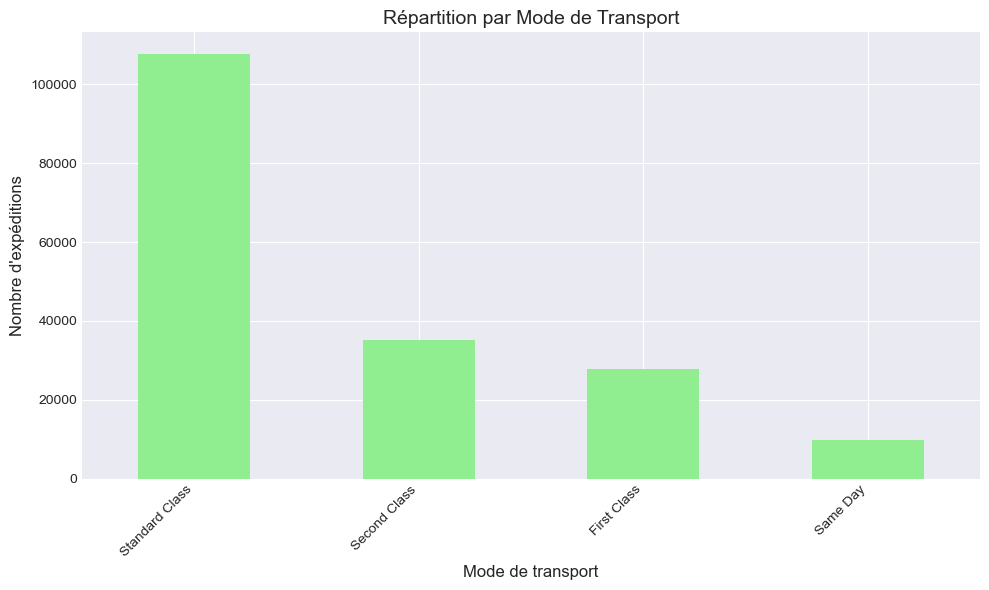

 Modes de transport les plus utilisés :
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


In [ ]:
# Répartition des modes de transport
plt.figure(figsize=(10, 6))
shipping_counts = df_subset['Shipping Mode'].value_counts()
shipping_counts.plot(kind='bar', color='lightgreen')

plt.title('Répartition par Mode de Transport', fontsize=14)
plt.xlabel('Mode de transport', fontsize=12)
plt.ylabel("Nombre d'expéditions", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(" Modes de transport les plus utilisés :")
print(shipping_counts.head())

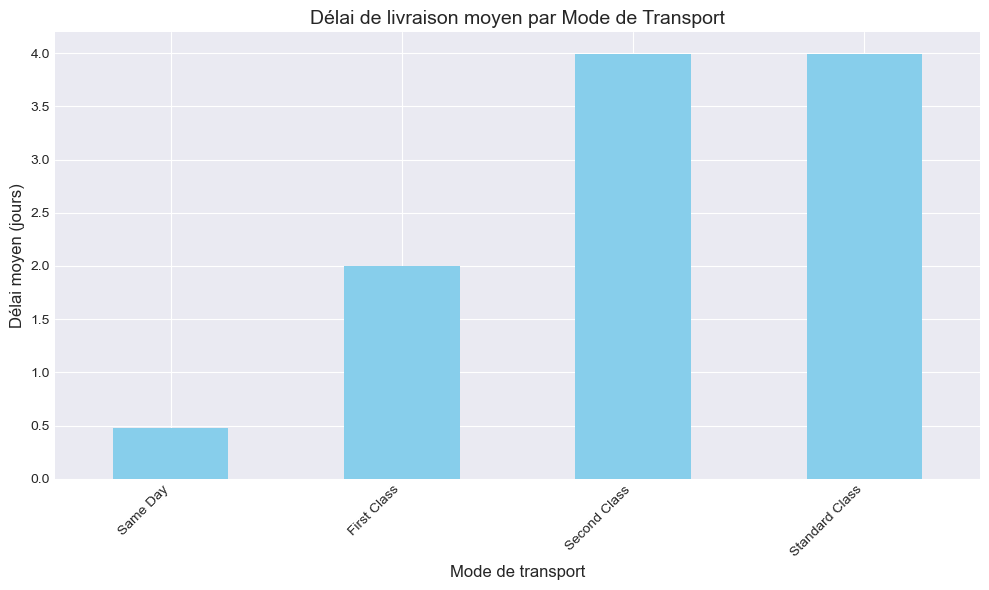

 Délai moyen par mode de transport :
Shipping Mode
Same Day          0.478279
First Class       2.000000
Second Class      3.990828
Standard Class    3.995907
Name: Days for shipping (real), dtype: float64


In [ ]:
# Délai moyen par mode de transport
plt.figure(figsize=(10, 6))
avg_delay_shipping = df_subset.groupby('Shipping Mode')['Days for shipping (real)'].mean().sort_values()
avg_delay_shipping.plot(kind='bar', color='skyblue')

plt.title('Délai de livraison moyen par Mode de Transport', fontsize=14)
plt.xlabel('Mode de transport', fontsize=12)
plt.ylabel('Délai moyen (jours)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(" Délai moyen par mode de transport :")
print(avg_delay_shipping)

## 10. Analyse des catégories de produits

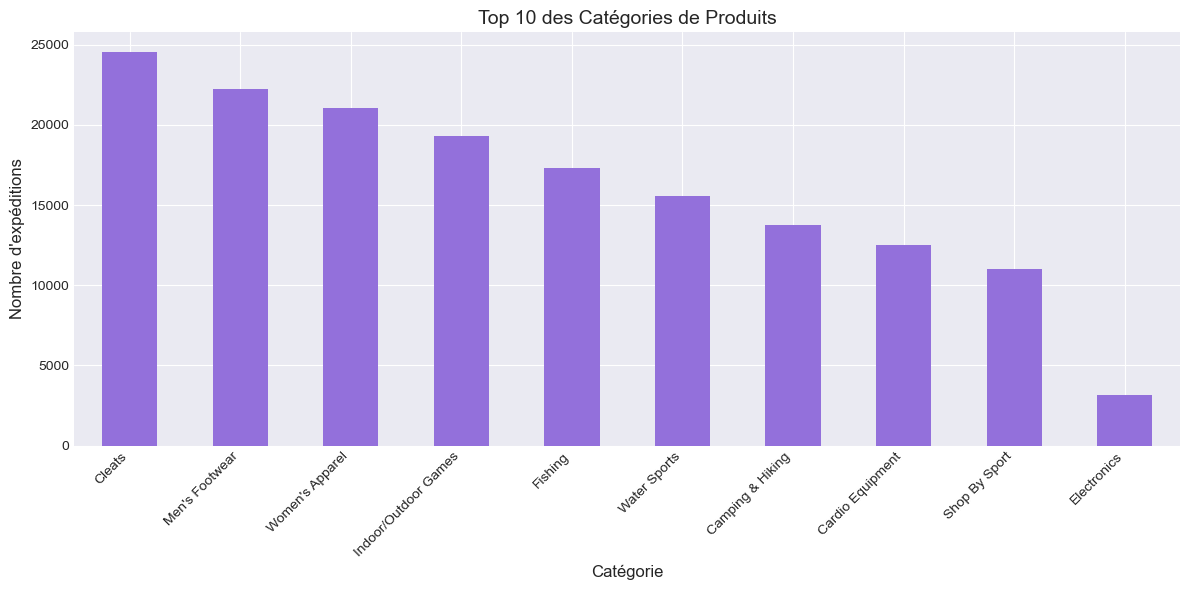

In [ ]:
# Top 10 des catégories de produits
plt.figure(figsize=(12, 6))
top_categories = df_subset['Category Name'].value_counts().head(10)
top_categories.plot(kind='bar', color='mediumpurple')

plt.title('Top 10 des Catégories de Produits', fontsize=14)
plt.xlabel('Catégorie', fontsize=12)
plt.ylabel("Nombre d'expéditions", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 11. Analyse géographique

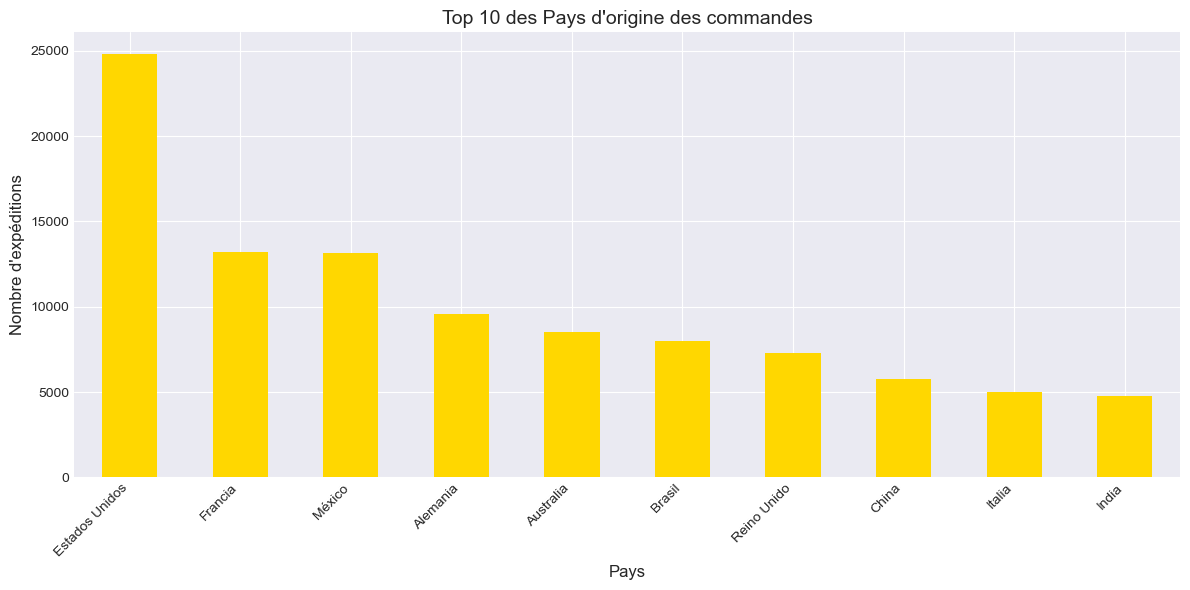

Principaux pays :
Order Country
Estados Unidos    24840
Francia           13222
México            13172
Alemania           9564
Australia          8497
Name: count, dtype: int64


In [ ]:
# Top 10 des pays d'origine des commandes
plt.figure(figsize=(12, 6))
top_countries = df_subset['Order Country'].value_counts().head(10)
top_countries.plot(kind='bar', color='gold')

plt.title('Top 10 des Pays d\'origine des commandes', fontsize=14)
plt.xlabel('Pays', fontsize=12)
plt.ylabel("Nombre d'expéditions", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Principaux pays :")
print(top_countries.head())

## 12. Analyse des bénéfices et marges

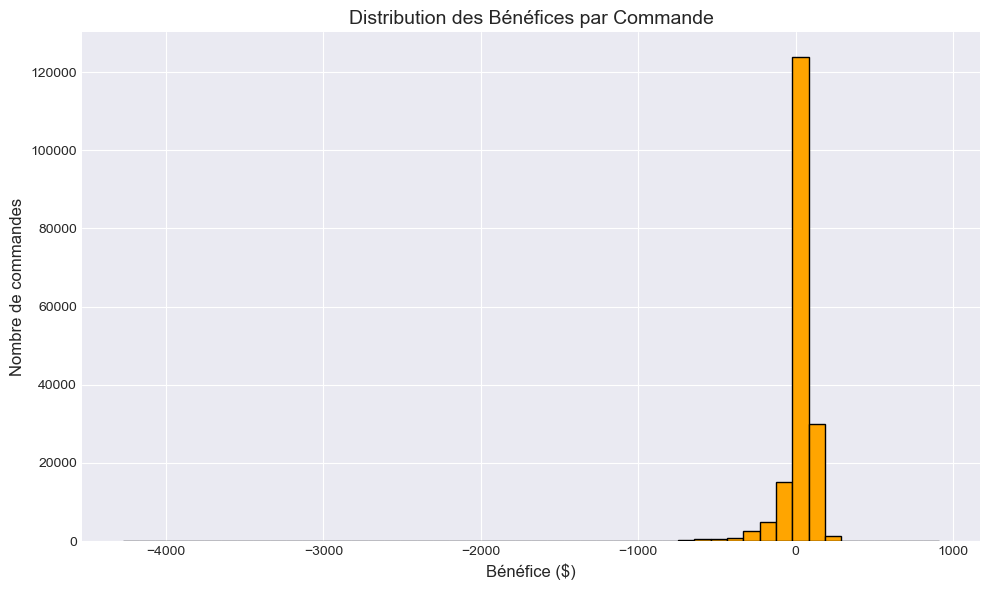

 Statistiques des bénéfices :
count    180519.000000
mean         21.974989
std         104.433526
min       -4274.979980
25%           7.000000
50%          31.520000
75%          64.800003
max         911.799988
Name: Benefit per order, dtype: float64


In [ ]:
# Distribution des bénéfices par commande
plt.figure(figsize=(10, 6))
plt.hist(df_subset['Benefit per order'].dropna(), bins=50, color='orange', edgecolor='black')
plt.title('Distribution des Bénéfices par Commande', fontsize=14)
plt.xlabel('Bénéfice ($)', fontsize=12)
plt.ylabel('Nombre de commandes', fontsize=12)
plt.tight_layout()
plt.show()

print(" Statistiques des bénéfices :")
print(df_subset['Benefit per order'].describe())

## 13. Matrice de corrélation

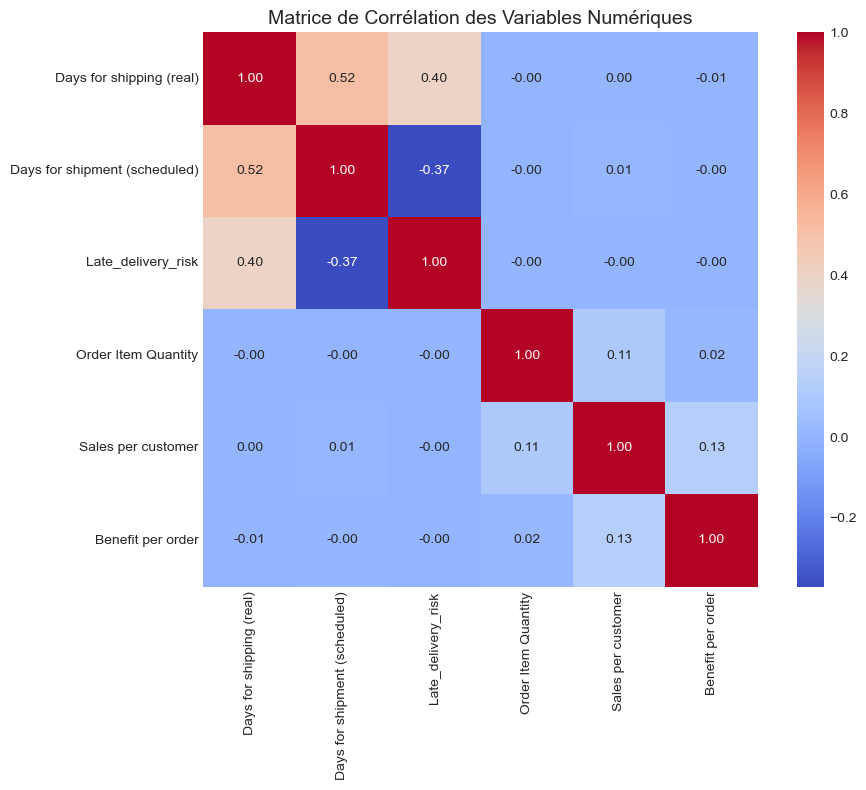

In [ ]:
# Sélection des colonnes numériques pour la corrélation
colonnes_numeriques = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Late_delivery_risk',
    'Order Item Quantity',
    'Sales per customer',
    'Benefit per order'
]

# Matrice de corrélation
corr_matrix = df_subset[colonnes_numeriques].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Matrice de Corrélation des Variables Numériques', fontsize=14)
plt.tight_layout()
plt.show()

## 14. Synthèse des observations

### Principales observations :

1. **Volume de données** : ~180 000 enregistrements, 53 colonnes
2. **Variable cible** : `Late_delivery_risk` (0/1) - Taux de retard global : [à compléter]%
3. **Transporteurs** : 
   - Le plus utilisé : [à compléter]
   - Le plus fiable : [à compléter] (taux de retard le plus faible)
4. **Modes de transport** : [à compléter] est le plus utilisé
5. **Colonnes à nettoyer** : [à compléter] colonnes ont des valeurs manquantes
6. **Corrélations** : Les variables [à compléter] sont corrélées avec le risque de retard

### Prochaines étapes :
- Nettoyer les données (valeurs manquantes, formats)
- Créer de nouvelles variables (feature engineering)
- Préparer les données pour le modèle de prédiction
- Construire le pipeline ETL

In [ ]:
# Sauvegarder le sous-ensemble pour l'étape suivante
df_subset.to_csv('../data/processed/dataco_subset.csv', index=False)
print(" Sous-ensemble sauvegardé dans 'data/processed/dataco_subset.csv'")

 Sous-ensemble sauvegardé dans 'data/processed/dataco_subset.csv'


## 15. Questions à approfondir

1. Pourquoi certains transporteurs ont-ils des taux de retard plus élevés ?
2. Existe-t-il des variations saisonnières dans les retards ?
3. Les retards sont-ils plus fréquents sur certaines routes (internationales vs nationales) ?
4. Comment le mode de transport influence-t-il le risque de retard ?
5. Quelles caractéristiques sont les plus prédictives d'un retard ?

Ces questions guideront la phase de modélisation.

---
**Fin de l'analyse exploratoire**

📌 Prochain notebook : `02_ETL.ipynb` - Nettoyage et transformation des données